# Модуль 10. Последовательности и внимание

Ноутбук к [модулю 10](https://drobyshevdev.github.io/lemma/modules/10-sequences-and-attention/).

Внимание строится **руками**, без обучения: цель — видеть каждый шаг, а не получить метрику. Нужны только `numpy` и `matplotlib`, считается за секунды.

**Читайте дважды.** Первый раз — сверху вниз, ничего не меняя. Второй — ломая: в конце каждого раздела есть, что сломать.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
np.set_printoptions(precision=3, suppress=True)

## 1. Внимание в пять строк

`softmax` по последней оси, устойчивый к переполнению вычитанием максимума. `attention` — ровно формула $\mathrm{softmax}(QK^\top/\sqrt{d_k})\,V$.

In [2]:
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)   # сдвиг не меняет softmax, но убирает переполнение
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def attention(Q, K, V, scale=True):
    d_k = K.shape[-1]
    scores = Q @ K.T
    if scale:
        scores = scores / np.sqrt(d_k)
    weights = softmax(scores, axis=-1)        # строка = распределение внимания одного запроса
    return weights @ V, weights

# Проверка формы на случайных матрицах: 3 запроса, 5 ключей, значения размерности 4.
Q = rng.standard_normal((3, 8)); K = rng.standard_normal((5, 8)); V = rng.standard_normal((5, 4))
out, w = attention(Q, K, V)
print("выход:", out.shape, " веса:", w.shape, " суммы весов по строке:", w.sum(1))

выход: (3, 4)  веса: (3, 5)  суммы весов по строке: [1. 1. 1.]


## 2. Зачем делить на $\sqrt{d}$

Скалярное произведение двух случайных векторов размерности $d$ имеет дисперсию $d$: это сумма $d$ независимых слагаемых. Значит, с ростом $d$ элементы $QK^\top$ раздуваются как $\sqrt{d}$, а softmax на больших числах схлопывается в one-hot — вся масса на одном ключе, градиент к остальным ноль.

Измерим это. Для каждой размерности возьмём много запросов, посчитаем среднюю **максимальную** массу softmax — насколько внимание близко к «победитель забирает всё» — с делением на $\sqrt{d}$ и без.

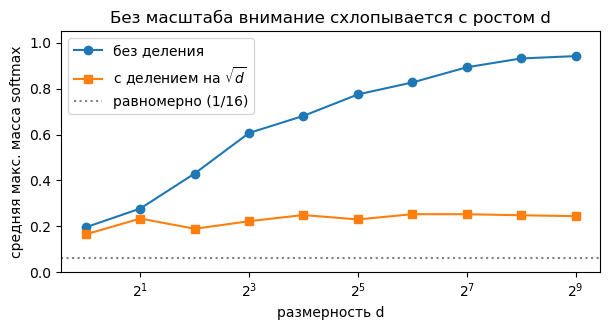

d=256  без деления: 0.932   с делением: 0.248


In [3]:
def mean_peak(d, n_keys=16, n_queries=400, scale=True):
    Q = rng.standard_normal((n_queries, d))
    K = rng.standard_normal((n_keys, d))
    scores = Q @ K.T
    if scale:
        scores = scores / np.sqrt(d)
    w = softmax(scores, axis=-1)
    return w.max(axis=1).mean()   # 1/n_keys = равномерно, 1.0 = one-hot

dims = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
peak_raw = [mean_peak(d, scale=False) for d in dims]
peak_scaled = [mean_peak(d, scale=True) for d in dims]

fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.plot(dims, peak_raw, "o-", label="без деления")
ax.plot(dims, peak_scaled, "s-", label=r"с делением на $\sqrt{d}$")
ax.axhline(1/16, ls=":", color="gray", label="равномерно (1/16)")
ax.set_xscale("log", base=2)
ax.set_xlabel("размерность d"); ax.set_ylabel("средняя макс. масса softmax")
ax.set_title("Без масштаба внимание схлопывается с ростом d")
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

print("d=256  без деления: %.3f   с делением: %.3f" % (peak_raw[-2], peak_scaled[-2]))

Без деления кривая ползёт к единице: при большой размерности одно случайное скалярное произведение оказывается заметно больше остальных, и softmax отдаёт ему почти всё. С делением масса держится у равномерной — внимание остаётся мягким, а значит, обучаемым.

**Сломать.** Поставьте `n_keys=64` и посмотрите, как ведёт себя «без деления»: чем больше ключей, тем острее пик. Уберите `axhline` и постройте не максимум, а энтропию распределения весов — это второй способ измерить то же самое.

## 3. Внимание как поиск

Внимание — это дифференцируемый lookup. Пусть ключи — «адреса» (ортогональные векторы позиций), значения — что лежит по адресу. Запрос, совпавший с адресом, достаёт значение.

In [4]:
n = 6
K_pos = np.eye(n)                  # ключи-адреса: позиция i = единичный вектор e_i
V_data = np.arange(10, 10 + n).reshape(n, 1).astype(float)   # значения: 10,11,...,15

# Запрос, нацеленный на позицию 3, но с шумом: похожесть с адресом 3 максимальна.
query = np.zeros((1, n)); query[0, 3] = 4.0
out, w = attention(query, K_pos, V_data)
print("веса внимания:", w.round(3))
print("достано:", out.round(3), " (ожидали ~13, значение по адресу 3)")

веса внимания: [[0.099 0.099 0.099 0.506 0.099 0.099]]
достано: [[12.704]]  (ожидали ~13, значение по адресу 3)


Вес почти весь на позиции 3, ответ — её значение. Это и есть «lookup, у которого есть производная»: чем острее совпадение запроса с адресом, тем чище выбор, но выбор всегда мягкий, поэтому по нему можно обучаться.

**Сломать.** Уменьшите `4.0` до `0.5` — совпадение размывается, ответ становится средним соседей. Сделайте два адреса неортогональными (`K_pos[2] = K_pos[3]`) и посмотрите, что достанет запрос.

## 4. Само-внимание на игрушечном предложении

Обучения нет, поэтому представления слов заданы руками — по нескольким «понятийным» осям (кто, движение, место, причина). Далёкое от настоящей сети, но достаточное, чтобы карта внимания что-то значила: слова, близкие по смыслу, дают большую похожесть.

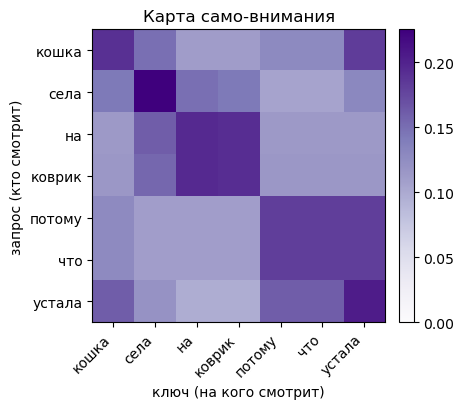

кошка    сильнее всего смотрит на  кошка
села     сильнее всего смотрит на  села
на       сильнее всего смотрит на  на
коврик   сильнее всего смотрит на  на
потому   сильнее всего смотрит на  потому
что      сильнее всего смотрит на  потому
устала   сильнее всего смотрит на  устала


In [5]:
tokens = ["кошка", "села", "на", "коврик", "потому", "что", "устала"]
#                 кто  движ  место причина
E = np.array([
    [1.0, 0.0, 0.0, 0.3],   # кошка
    [0.6, 1.0, 0.4, 0.0],   # села
    [0.0, 0.3, 1.0, 0.0],   # на
    [0.0, 0.2, 1.0, 0.0],   # коврик
    [0.0, 0.0, 0.0, 1.0],   # потому
    [0.0, 0.0, 0.0, 1.0],   # что
    [0.7, 0.0, 0.0, 1.0],   # устала
])

out, W = attention(E, E, E)          # Q = K = V = E: чистое само-внимание

fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(W, cmap="Purples", vmin=0)
ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens, rotation=45, ha="right")
ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens)
ax.set_xlabel("ключ (на кого смотрит)"); ax.set_ylabel("запрос (кто смотрит)")
ax.set_title("Карта само-внимания")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

top = W.argmax(1)
for i, t in enumerate(tokens):
    print(f"{t:8s} сильнее всего смотрит на  {tokens[top[i]]}")

«устала» тянется к «кошка» и к причинным словам, «коврик» — к «на» и «села». Это та же карта, что в интерактивной фигуре модуля, только посчитанная из представлений, а не нарисованная.

**Сломать.** Обнулите причинную ось (`E[:, 3] = 0`) — «потому», «что», «устала» потеряют связь. Уберите деление на $\sqrt{d}$ в `attention` (`scale=False`) и посмотрите, насколько резче станет карта.

## 5. Внимание не знает порядка

Переставим слова и повторим. Внимание — операция над множеством: тот же набор представлений в другом порядке даёт тот же набор ответов, только переставленный. Порядок слов слой не видит.

In [6]:
perm = np.array([3, 1, 2, 0, 6, 5, 4])   # переставили кошка<->коврик, устала<->потому
out_perm, _ = attention(E[perm], E[perm], E[perm])

# Ответы совпадают с точностью до перестановки: сравним ответ для «села» в обоих порядках.
i_sela = tokens.index("села")
j_sela = list(perm).index(i_sela)
print("ответ для «села», исходный порядок: ", out[i_sela].round(3))
print("ответ для «села», переставленный:   ", out_perm[j_sela].round(3))
print("совпадают:", np.allclose(out[i_sela], out_perm[j_sela]))

ответ для «села», исходный порядок:  [0.368 0.299 0.382 0.383]
ответ для «села», переставленный:    [0.368 0.299 0.382 0.383]
совпадают: True


Ответ для слова зависит только от того, какие слова вокруг, но не от их порядка. Для языка это дефект: «кошка села на коврик» и «коврик села на кошку» должны различаться.

## 6. Позиционное кодирование

Чиним, добавляя к каждому слову вектор, зависящий от позиции. Классический вариант — синусоиды разных частот: у каждой позиции свой узор, и близкие позиции похожи, далёкие — нет.

без позиций — набор ответов при перестановке сохраняется: True
с позициями — набор ответов при перестановке сохраняется: False


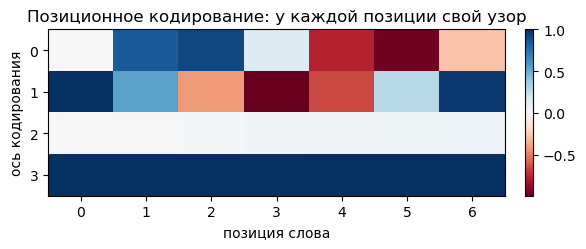

In [7]:
def positional_encoding(length, d):
    pos = np.arange(length)[:, None]
    i = np.arange(d)[None, :]
    angle = pos / np.power(10000.0, (2 * (i // 2)) / d)
    pe = np.where(i % 2 == 0, np.sin(angle), np.cos(angle))
    return pe

d = E.shape[1]
PE = positional_encoding(len(tokens), d)
E_pos = E + 0.6 * PE                       # представление теперь несёт и смысл, и позицию

out_pos, _ = attention(E_pos, E_pos, E_pos)
# Переставляем слова и добавляем позиции ПО НОВЫМ местам: тот же токен на другом
# месте получает другой позиционный вектор. В разделе 5 позиции не было вовсе,
# поэтому там перестановка ничего не меняла по сути.
E_pos_perm = E[perm] + 0.6 * PE
out_pos_perm, _ = attention(E_pos_perm, E_pos_perm, E_pos_perm)

def sorted_rows(A):                        # набор строк без учёта их порядка
    return A[np.lexsort(np.round(A, 6).T[::-1])]

print("без позиций — набор ответов при перестановке сохраняется:",
      np.allclose(sorted_rows(out), sorted_rows(out_perm)))
print("с позициями — набор ответов при перестановке сохраняется:",
      np.allclose(sorted_rows(out_pos), sorted_rows(out_pos_perm)))

fig, ax = plt.subplots(figsize=(6.0, 2.6))
im = ax.imshow(PE.T, cmap="RdBu", aspect="auto")
ax.set_xlabel("позиция слова"); ax.set_ylabel("ось кодирования")
ax.set_title("Позиционное кодирование: у каждой позиции свой узор")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

Первая строка — `True`: без позиций перестановка слов лишь переставляет ответы, набор тот же. Вторая — `False`: с позициями набор ответов другой. Слой начал различать порядок, и «кошка села на коврик» перестало быть тем же, что «коврик села на кошку».

**Сломать.** Увеличьте вес `0.6` до `3.0` — позиция забьёт смысл, и карта внимания станет про «кто рядом стоит», а не «кто по смыслу связан». Поставьте `0.0` — вернётесь к разделу 5.

## Что дальше

Стопка таких блоков — внимание, MLP, остаток, норма, — обученная предсказывать следующее слово, и есть языковая модель. Как её обучают, запускают и, главное, как честно оценивают — [модуль 11](https://drobyshevdev.github.io/lemma/programme/).

И тот же вопрос, что во всём курсе: заявленное улучшение архитектуры внимания переживает смену зерна и сравнение с честной базой — или это разница в том, сколько труда вложили в свой вариант и сколько в чужой? К модулю 10 у вас есть инструмент проверить это руками.